In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib

In [4]:
hs = pd.read_csv("bng_house_data.csv")
hs.shape

(13320, 9)

In [5]:
hs.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [6]:
hs1 = hs.drop(['area_type','availability','society','balcony'],axis = 'columns')
hs1.isnull().sum()

location       1
size          16
total_sqft     0
bath          73
price          0
dtype: int64

In [7]:
hs2 = hs1.dropna()
hs2.isnull().sum()
hs2.shape

(13246, 5)

In [8]:
hs2['bhk'] = hs2['size'].apply(lambda x: int(x.split(' ')[0]))       

C:\Users\eswar\AppData\Local\Temp\ipykernel_14624\3129447843.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hs2['bhk'] = hs2['size'].apply(lambda x: int(x.split(' ')[0]))


In [9]:
hs2

,location,size,total_sqft,bath,price,bhk
0,Electronic City Phase II,2 BHK,1056,2.0,39.07,2
1,Chikka Tirupathi,4 Bedroom,2600,5.0,120.00,4
2,Uttarahalli,3 BHK,1440,2.0,62.00,3
3,Lingadheeranahalli,3 BHK,1521,3.0,95.00,3
4,Kothanur,2 BHK,1200,2.0,51.00,2
...,...,...,...,...,...,...
13315,Whitefield,5 Bedroom,3453,4.0,231.00,5
13316,Richards Town,4 BHK,3600,5.0,400.00,4
13317,Raja Rajeshwari Nagar,2 BHK,1141,2.0,60.00,2
13318,Padmanabhanagar,4 BHK,4689,4.0,488.00,4


In [10]:
hs2['bhk'].value_counts()

bhk
2     5527
3     4832
4     1395
1      649
5      353
6      221
7      100
8       89
9       54
10      14
11       4
27       1
19       1
16       1
43       1
14       1
12       1
13       1
18       1
Name: count, dtype: int64

In [11]:
hs2[hs2.bhk>20]

,location,size,total_sqft,bath,price,bhk
1718,2Electronic City Phase II,27 BHK,8000,27.0,230.0,27
4684,Munnekollal,43 Bedroom,2400,40.0,660.0,43


In [12]:
hs2.total_sqft.unique()

array(['1056', '2600', '1440', ..., '1133 - 1384', '774', '4689'],
      shape=(2067,), dtype=object)

In [13]:
def  is_float(x):
    try:
        float(x)
    except:
        return False
    return True    

In [14]:
hs2[~hs2['total_sqft'].apply(is_float)].head(10)

,location,size,total_sqft,bath,price,bhk
30,Yelahanka,4 BHK,2100 - 2850,4.0,186.000,4
122,Hebbal,4 BHK,3067 - 8156,4.0,477.000,4
137,8th Phase JP Nagar,2 BHK,1042 - 1105,2.0,54.005,2
165,Sarjapur,2 BHK,1145 - 1340,2.0,43.490,2
188,KR Puram,2 BHK,1015 - 1540,2.0,56.800,2
410,Kengeri,1 BHK,34.46Sq. Meter,1.0,18.500,1
549,Hennur Road,2 BHK,1195 - 1440,2.0,63.770,2
648,Arekere,9 Bedroom,4125Perch,9.0,265.000,9
661,Yelahanka,2 BHK,1120 - 1145,2.0,48.130,2
672,Bettahalsoor,4 Bedroom,3090 - 5002,4.0,445.000,4


In [15]:
def cover_sqft_num(x):
    token = x.split('-')
    if len(token)==2:
        return (float(token[0])+float(token[1]))/2
    try:
        return float(x)
    except:
        return None

In [16]:
cover_sqft_num('34.46Sq. Meter')

In [17]:
hs2['total_sqft'] = hs2['total_sqft'].apply(cover_sqft_num)

C:\Users\eswar\AppData\Local\Temp\ipykernel_14624\4130717221.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hs2['total_sqft'] = hs2['total_sqft'].apply(cover_sqft_num)


In [18]:
loc_stats = hs2.groupby('location')['location'].agg('count')
loc_stats[1:50]

location
 Banaswadi                                          1
 Basavangudi                                        1
 Bhoganhalli                                        1
 Devarabeesana Halli                                6
 Devarachikkanahalli                               14
 Electronic City                                    2
 Mysore Highway                                     4
 Rachenahalli                                       2
 Sector 1 HSR Layout                                1
 Thanisandra                                        3
 Whitefield                                         1
 ittamadu                                           1
 south                                              2
1 Annasandrapalya                                   1
1 Giri Nagar                                        1
1 Immadihalli                                       1
1 Ramamurthy Nagar                                  1
12th cross srinivas nagar banshankari 3rd stage     1
1A Block Koramangal

In [19]:
len(loc_stats[loc_stats <=10])

1063

In [20]:
loc_les_10 = loc_stats[loc_stats <=10]
len(loc_les_10)
hs2.head(4)

,location,size,total_sqft,bath,price,bhk
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3


In [21]:
hs2.location = hs2['location'].apply(lambda x: 'other' if x in loc_les_10 else x)
hs2.location.nunique()

C:\Users\eswar\AppData\Local\Temp\ipykernel_14624\3869626176.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hs2.location = hs2['location'].apply(lambda x: 'other' if x in loc_les_10 else x)


242

In [22]:
hs3 = hs2[~(hs2.total_sqft/hs2.bhk<300)]
hs3.head(20)


,location,size,total_sqft,bath,price,bhk
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3
4,Kothanur,2 BHK,1200.0,2.0,51.00,2
5,Whitefield,2 BHK,1170.0,2.0,38.00,2
6,Old Airport Road,4 BHK,2732.0,4.0,204.00,4
7,Rajaji Nagar,4 BHK,3300.0,4.0,600.00,4
8,Marathahalli,3 BHK,1310.0,3.0,63.25,3
10,Whitefield,3 BHK,1800.0,2.0,70.00,3


In [23]:
hs3.shape

(12502, 6)

In [24]:
hs3.bath.value_counts()
hs3['price_per_sqft']=hs3['price']*100000/hs3['total_sqft']

C:\Users\eswar\AppData\Local\Temp\ipykernel_14624\1798599859.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hs3['price_per_sqft']=hs3['price']*100000/hs3['total_sqft']


In [25]:
def remove_price_sqft(df):
    df_out = pd.DataFrame()
    for key,subdf in df.groupby('location'):
        m = np.mean(subdf.price_per_sqft)
        st = np.std(subdf.price_per_sqft)
        outliers =subdf[(subdf.price_per_sqft>(m-st))&(subdf.price_per_sqft<(m+st))]
        df_out = pd.concat([df_out,outliers],ignore_index =True)
    return df_out    
                          

hs4 =remove_price_sqft(hs3)
hs4.location.value_counts()
hs4.shape

(10244, 7)

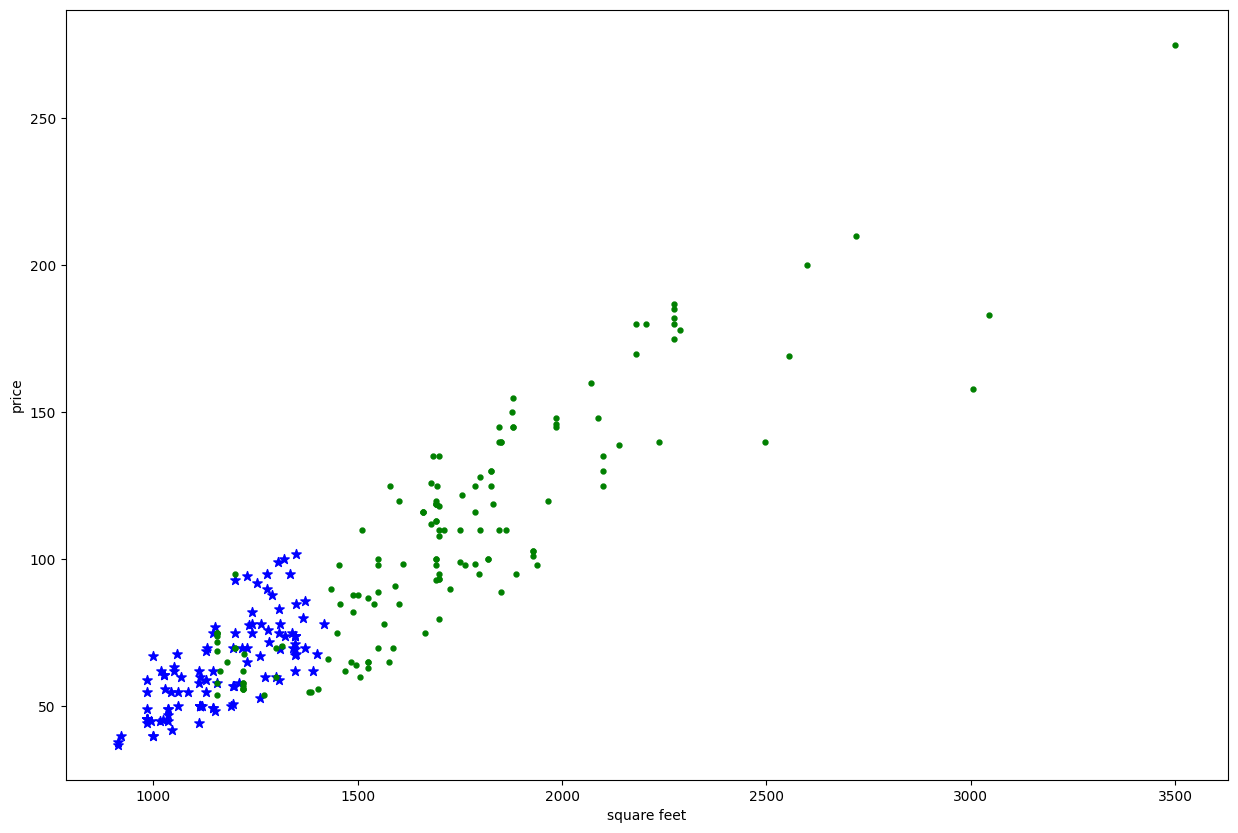

In [26]:
def scatter_plot(df,location):
    dfbhk2 = df[(df.location == location)&(df.bhk==2)]
    dfbhk3 = df[(df.location == location)&(df.bhk==3)]
    matplotlib.rcParams['figure.figsize']=(15,10)
    plt.scatter(dfbhk2.total_sqft,dfbhk2.price,marker='*',color ='blue',s=50)
    plt.scatter(dfbhk3.total_sqft,dfbhk3.price,marker ='.',color = 'green',s=50)
    plt.xlabel('square feet')
    plt.ylabel('price')
scatter_plot(hs4,'Sarjapur  Road')   

In [27]:
def remove_out_liears(df):
    exclude_indices = np.array([])
    for location,location_df in df.groupby('location'):
        bhk_stats = {}
        for bhk,bhk_df in location_df.groupby('bhk'):
            bhk_stats[bhk]={
                'mean':np.mean(bhk_df.price_per_sqft),
                'std':np.std(bhk_df.price_per_sqft),
                'count':bhk_df.shape[0]
            }
        for bhk,bhk_df in location_df.groupby('bhk'):
            stats = bhk_stats.get(bhk-1)
            if stats and stats['count']>5:
                exclude_indices = np.append(exclude_indices,bhk_df[bhk_df.price_per_sqft<(stats['mean'])].index.values)
    return df.drop(exclude_indices,axis = 'index')      
            
            

hs5= remove_out_liears(hs4)
hs5.shape
        

(7342, 7)

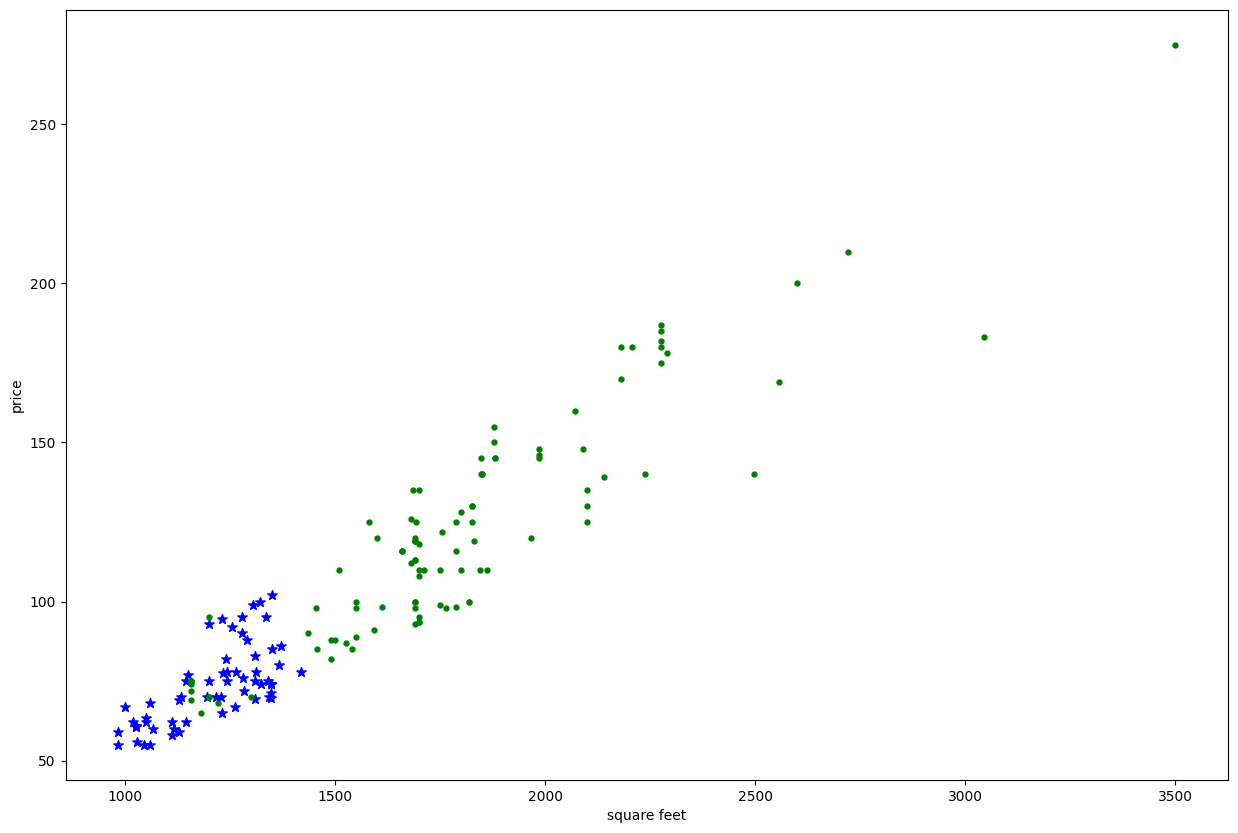

In [28]:
scatter_plot(hs5,'Sarjapur  Road')   

In [29]:
hs5.bath.unique()

array([ 2.,  3.,  4.,  5.,  8.,  1.,  6.,  7.,  9., 12., 16., 13.])

In [30]:
hs5[hs5.bath>=10]

,location,size,total_sqft,bath,price,bhk,price_per_sqft
5271,Neeladri Nagar,10 BHK,4000.0,12.0,160.0,10,4000.000000
8481,other,10 BHK,12000.0,12.0,525.0,10,4375.000000
8570,other,16 BHK,10000.0,16.0,550.0,16,5500.000000
9309,other,11 BHK,6000.0,12.0,150.0,11,2500.000000
9641,other,13 BHK,5425.0,13.0,275.0,13,5069.124424


In [31]:
hs6=hs5[~(hs5.bath>hs5.bhk+2)]
hs6.shape

(7338, 7)

In [32]:
hs7 = hs6.drop(['size','price_per_sqft'],axis = 'columns')
hs7.head(3)

,location,total_sqft,bath,price,bhk
1,Devarachikkanahalli,1250.0,2.0,40.0,2
2,Devarachikkanahalli,1200.0,2.0,83.0,2
3,Devarachikkanahalli,1170.0,2.0,40.0,2


In [33]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
hs7.location = le.fit_transform(hs7.location)
x = hs7.drop(['price'],axis = 'columns')
y = hs7.price.astype(int)
y = pd.DataFrame(y)


In [34]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size =0.2,random_state = 10)

In [35]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train,y_train)
model.score(x_test,y_test)

0.7023243649259341

In [36]:
from sklearn.model_selection import ShuffleSplit
from sklearn.model_selection import cross_val_score
cv = ShuffleSplit(n_splits=5,test_size =0.2,random_state = 0)
cross_val_score(LinearRegression(),x,y,cv=cv)

array([0.66646357, 0.70520122, 0.697561  , 0.68463275, 0.69863802])

In [37]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Lasso
from sklearn.tree import DecisionTreeRegressor
def grid_cv(x,y):
    algs = {
        'linear_reg':{
            'model':LinearRegression(),
            'params':{
                'fit_intercept':[True,False]
            }}}
       
    scores=[]
    cv= ShuffleSplit(n_splits=5,test_size=0.2,random_state=0)
    for algo_name,config in algs.items():
        gs = GridSearchCV(config['model'],config['params'],cv=cv,return_train_score=False)
        gs.fit(x,y)
        scores.append({
            'model':algo_name,
            'best_score':gs.best_score_,
            'best_params':gs.best_params_
        })
    return pd.DataFrame(scores,columns=['model','best_score','best_params'])
grid_cv(x,y)        
        
                
            

,model,best_score,best_params
0,linear_reg,0.690499,{'fit_intercept': True}


In [38]:
location = pd.get_dummies(hs6.location).astype(int)
location

,Devarachikkanahalli,1st Block Jayanagar,1st Phase JP Nagar,2nd Phase Judicial Layout,2nd Stage Nagarbhavi,5th Block Hbr Layout,5th Phase JP Nagar,6th Phase JP Nagar,7th Phase JP Nagar,8th Phase JP Nagar,...,Vishveshwarya Layout,Vishwapriya Layout,Vittasandra,Whitefield,Yelachenahalli,Yelahanka,Yelahanka New Town,Yelenahalli,Yeshwanthpur,other
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10235,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
10236,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
10239,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
10240,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [39]:
hs8 = pd.concat([hs6,location.drop('other',axis='columns')],axis = 'columns')
hs8.head(4)

,location,size,total_sqft,bath,price,bhk,price_per_sqft,Devarachikkanahalli,1st Block Jayanagar,1st Phase JP Nagar,...,Vijayanagar,Vishveshwarya Layout,Vishwapriya Layout,Vittasandra,Whitefield,Yelachenahalli,Yelahanka,Yelahanka New Town,Yelenahalli,Yeshwanthpur
1,Devarachikkanahalli,2 BHK,1250.0,2.0,40.0,2,3200.000000,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,Devarachikkanahalli,2 Bedroom,1200.0,2.0,83.0,2,6916.666667,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,Devarachikkanahalli,2 BHK,1170.0,2.0,40.0,2,3418.803419,1,0,0,...,0,0,0,0,0,0,0,0,0,0
4,Devarachikkanahalli,3 BHK,1425.0,2.0,65.0,3,4561.403509,1,0,0,...,0,0,0,0,0,0,0,0,0,0


In [40]:
hs9 = hs8.drop(['location','size','price_per_sqft'],axis = 'columns')
hs9.head(4)

,total_sqft,bath,price,bhk,Devarachikkanahalli,1st Block Jayanagar,1st Phase JP Nagar,2nd Phase Judicial Layout,2nd Stage Nagarbhavi,5th Block Hbr Layout,...,Vijayanagar,Vishveshwarya Layout,Vishwapriya Layout,Vittasandra,Whitefield,Yelachenahalli,Yelahanka,Yelahanka New Town,Yelenahalli,Yeshwanthpur
1,1250.0,2.0,40.0,2,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1200.0,2.0,83.0,2,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1170.0,2.0,40.0,2,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1425.0,2.0,65.0,3,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [41]:
x1 = hs9.drop(['price'],axis = 'columns')
y2 = hs9.price.astype(int)

In [42]:
x_train1,x_test1,y_train1,y_test1 = train_test_split(x1,y2,test_size = 0.2,random_state = 10)
model2 = LinearRegression()
model2.fit(x_train1,y_train1)
model2.score(x_test1,y_test1)

0.8393327572678033

In [43]:
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
cv = ShuffleSplit(n_splits =10,test_size = 0.2,random_state = 24)
cross_val_score(LinearRegression(),x1,y2,cv=cv)

array([0.87998779, 0.84556453, 0.86433193, 0.88262994, 0.77603789,
       0.85150119, 0.82868252, 0.8568632 , 0.80002784, 0.88115304])

In [44]:
print("hello")

hello


In [45]:
def best_model(x,y):
    algorm = {
        "linear":{
            "model":LinearRegression(),
            "params":{
                "fit_intercept":[True,False]}},
         'lasso':{
            'model':Lasso(),
            'params':{
                'alpha':[1,2],
                'selection':['random','cyclic']
            }
        },
        'decision_tree':{
            'model':DecisionTreeRegressor(),
            'params':{
                'splitter':['best','random'],
                'criterion':['poisson','friedman_mse']
                             }}}
       
    scores = []
    cv = ShuffleSplit(n_splits=5,test_size=0.2,random_state =5)
    for algo_names,configs in algorm.items():
        gs1 = GridSearchCV(configs['model'],configs['params'],cv=cv,return_train_score =False)
        gs1.fit(x,y)
        scores.append({
            "model":algo_names,
            "best_score":gs1.best_score_,
            "best_params":gs1.best_params_})
        
    return pd.DataFrame(scores,columns = ["model","best_score","best_params"])
  
best_model(x1,y2)    
        
        

,model,best_score,best_params
0,linear,0.833559,{'fit_intercept': False}
1,lasso,0.697564,"{'alpha': 2, 'selection': 'cyclic'}"
2,decision_tree,0.661082,"{'criterion': 'poisson', 'splitter': 'best'}"


In [52]:
def predict_price(location,sqfeet,bhk,bath):
    loc_index = np.where(x1.columns==location)[0][0]
    x = np.zeros(len(x1.columns))
    x[0]=sqfeet
    x[1]=bhk
    x[2]=bath
    if loc_index>=0:
        x[loc_index]=1
    return model2.predict([x])[0]  

    

In [53]:
predict_price('Vishveshwarya Layout',1000,3,3)

C:\Users\eswar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


np.float64(20.324450309306016)

In [60]:
def col(location,sqfeet,bhk,bath):
    loc_index = np.where(x1.columns==location)[0][0]
    x= np.zeros(len(x1.columns))
    x[0]=sqfeet
    x[1]= bhk
    x[2] = bath
    if loc_index>=0:
        x[loc_index]=1
    return model2.predict([x])[0]
col('Vijayanagar',1000,3,2)

C:\Users\eswar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


np.float64(74.75102768816998)

In [61]:
import pickle
with open("bng_house_data","wb")as f:
    pickle.dump(model2,f)

In [66]:
import json
columns={
    "colmn":[ col.lower() for col in x1.columns]
}
with open("columns.json","w") as f:
    f.write(json.dumps(columns))